# Dynamic Inseption LSTM Model

### Imports

In [9]:
import random
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.utils import Sequence
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, GlobalAveragePooling2D, Concatenate, Dropout
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.preprocessing.image import load_img
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, precision_recall_curve

### Constants

In [10]:
# InceptionV3 default input size
image_size = (299, 299)

### Definitions

##### For Visualisations

In [11]:
# Visualise Sample Images
def show_sample_images(image_paths, labels, num_samples=5):
    plt.figure(figsize=(12, 6))
    for i in range(num_samples):
        index = random.randint(0, len(image_paths) - 1)
        img = load_img(image_paths[index], target_size=(299, 299))
        plt.subplot(1, num_samples, i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title("Genuine" if labels[index] == 0 else "Forged")
    plt.show()

In [12]:
# Training Progress Visualisation
def plot_training_history(history):
    plt.figure(figsize=(12, 5))
    
    # Loss Curve
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training & Validation Loss")
    plt.legend()
    
    # Accuracy Curve
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Training & Validation Accuracy")
    plt.legend()
    
    plt.show()

In [13]:
# Feature Distribution
def plot_feature_distribution(features):
    plt.figure(figsize=(10, 5))
    plt.hist(features.flatten(), bins=50, alpha=0.75, color='blue')
    plt.xlabel("Feature Value")
    plt.ylabel("Frequency")
    plt.title("Distribution of Handcrafted Features")
    plt.show()

In [14]:
# Confusion Matrix Heatmap
def plot_confusion_matrix(conf_matrix):
    plt.figure(figsize=(6, 5))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Genuine', 'Forged'], yticklabels=['Genuine', 'Forged'])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

In [15]:
# AUC/ROC Curve
def plot_roc_curve(y_test, y_pred_probs):
    fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

In [16]:
# Precision-Recall Curve
def plot_precision_recall_curve(y_test, y_pred_probs):
    precision, recall, _ = precision_recall_curve(y_test, y_pred_probs)
    
    plt.figure(figsize=(7, 5))
    plt.plot(recall, precision, color='green', lw=2)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.show()

### Custom Data Generator

In [17]:
class SignatureDataGenerator(Sequence):
    def __init__(self, image_paths, handcrafted_features, labels, batch_size=32, shuffle=True):
        self.image_paths = image_paths
        self.handcrafted_features = handcrafted_features
        self.labels = labels
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.image_paths))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.image_paths) / self.batch_size))  # Handle last batch

    def __getitem__(self, index):
        # Get batch indexes
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]

        # Load batch data
        batch_images = np.array([self.load_image(self.image_paths[i]) for i in batch_indexes])
        batch_handcrafted = np.array([self.handcrafted_features[i] for i in batch_indexes])
        batch_labels = np.array([self.labels[i] for i in batch_indexes])

        return (batch_images, batch_handcrafted.reshape(-1, batch_handcrafted.shape[1], 1)), batch_labels

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

    @staticmethod
    def load_image(image_path):
        img = tf.keras.preprocessing.image.load_img(image_path, target_size=image_size)
        img = tf.keras.preprocessing.image.img_to_array(img)
        return tf.keras.applications.inception_v3.preprocess_input(img)

### Process

Data Loading

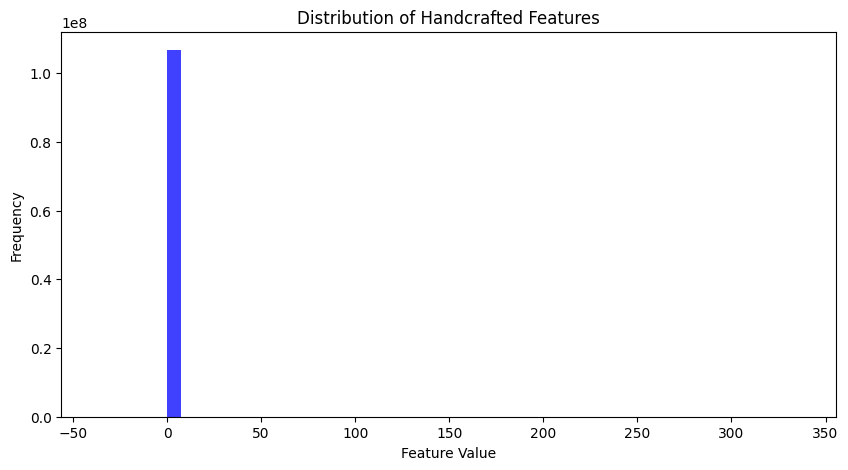

In [18]:
# Load handcrafted features
data = pd.read_csv("../Dataset/Features/signature_features.csv")
labels = data["label"].values
handcrafted_features = data.iloc[:, 2:].values  # Skip filename and label columns

# Display Feature Distibution
plot_feature_distribution(handcrafted_features)

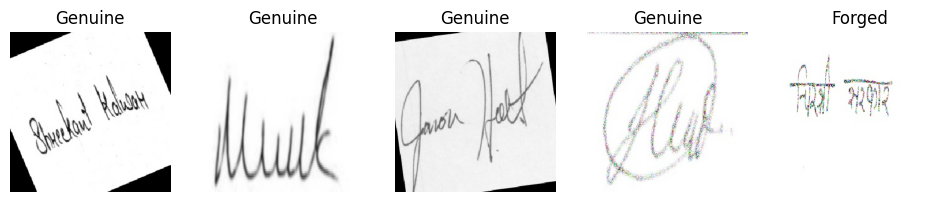

In [19]:
# Image paths
image_paths = [f"../Dataset/Processing/AugmentedDataset/{'Genuine' if label == 0 else 'Forged'}/{file}" 
               for file, label in zip(data["filename"], labels)]

# Split dataset
train_img_paths, val_img_paths, train_handcrafted, val_handcrafted, y_train, y_val = train_test_split(
    image_paths, handcrafted_features, labels, test_size=0.2, random_state=42, stratify=labels)

# Display sample images from slip datset
show_sample_images(train_img_paths, y_train)

Model Training

In [20]:
# Create data generators
batch_size = 32
train_generator = SignatureDataGenerator(train_img_paths, train_handcrafted, y_train, batch_size=batch_size)
val_generator = SignatureDataGenerator(val_img_paths, val_handcrafted, y_val, batch_size=batch_size)

In [21]:
# CNN Feature Extractor (InceptionV3)
inception_base = InceptionV3(weights=None, include_top=False, input_shape=(299, 299, 3))
cnn_output = GlobalAveragePooling2D()(inception_base.output)

# LSTM for sequence modeling
lstm_input = Input(shape=(train_handcrafted.shape[1], 1))  # Handcrafted features
lstm_layer = LSTM(128, return_sequences=False)(lstm_input)

# Combine CNN and LSTM
merged = Concatenate()([cnn_output, lstm_layer])
dense_layer = Dense(128, activation='relu')(merged)
dropout_layer = Dropout(0.5)(dense_layer)
output_layer = Dense(1, activation='sigmoid')(dropout_layer)

In [22]:
# Define hybrid model
model = Model(inputs=[inception_base.input, lstm_input], outputs=output_layer)

# Compile model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [23]:
# Train model using data generators
history = model.fit(train_generator, validation_data=val_generator, epochs=35)

Epoch 1/35


d:\Documents\SoftwareDevelopment\Projects\Signature-Forgery-Detection-System\.venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


700/700 ━━━━━━━━━━━━━━━━━━━━ 1721s 2s/step - accuracy: 0.6938 - loss: 0.6206 - val_accuracy: 0.6873 - val_loss: 1.0246
Epoch 2/35
700/700 ━━━━━━━━━━━━━━━━━━━━ 1645s 2s/step - accuracy: 0.7744 - loss: 0.4623 - val_accuracy: 0.4943 - val_loss: 2.8809
Epoch 3/35
700/700 ━━━━━━━━━━━━━━━━━━━━ 1635s 2s/step - accuracy: 0.7974 - loss: 0.4173 - val_accuracy: 0.6716 - val_loss: 0.8157
Epoch 4/35
700/700 ━━━━━━━━━━━━━━━━━━━━ 1622s 2s/step - accuracy: 0.8235 - loss: 0.3702 - val_accuracy: 0.5475 - val_loss: 1.6278
Epoch 5/35
700/700 ━━━━━━━━━━━━━━━━━━━━ 1619s 2s/step - accuracy: 0.8439 - loss: 0.3370 - val_accuracy: 0.6837 - val_loss: 0.8796
Epoch 6/35
700/700 ━━━━━━━━━━━━━━━━━━━━ 1618s 2s/step - accuracy: 0.8658 - loss: 0.3080 - val_accuracy: 0.6479 - val_loss: 0.8583
Epoch 7/35
700/700 ━━━━━━━━━━━━━━━━━━━━ 1620s 2s/step - accuracy: 0.8778 - loss: 0.2793 - val_accuracy: 0.7284 - val_loss: 0.5327
Epoch 8/35
700/700 ━━━━━━━━━━━━━━━━━━━━ 1615s 2s/step - accuracy: 0.8923 - loss: 0.2551 - val_accurac

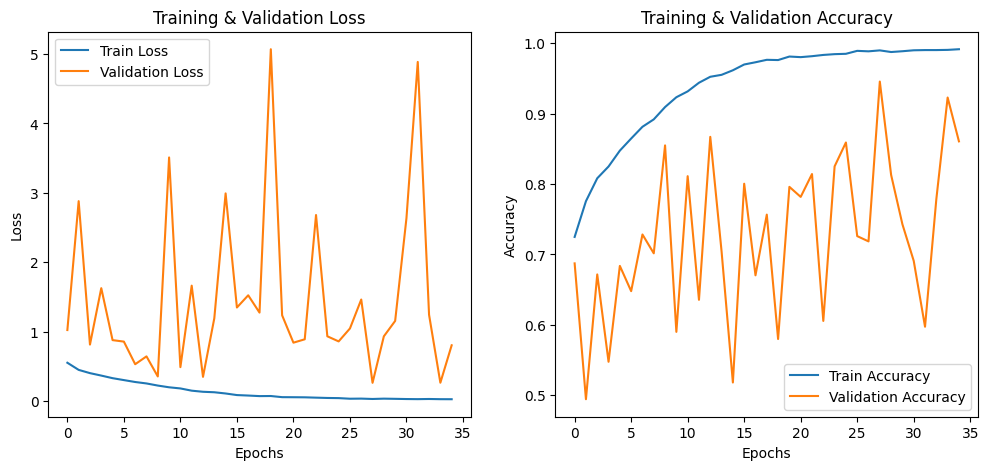

In [24]:
# Plot training history
plot_training_history(history)

In [25]:
# Save model
model.save("../Model/signature_forgery_detection_model.h5")

print("Model training completed and saved!")

Model training completed and saved!


### Testing and Evaluations

In [26]:
# Load trained model
if 'model' not in globals():
    model = tf.keras.models.load_model("../Model/signature_forgery_detection_model.h5")

In [27]:
# Load test images and handcrafted features
X_test_img = np.array([SignatureDataGenerator.load_image(path) for path in val_img_paths])
X_test_handcrafted = val_handcrafted.reshape(-1, val_handcrafted.shape[1], 1)
y_test = y_val  # Labels

In [28]:
# Predict on test set
y_pred_probs = model.predict([X_test_img, X_test_handcrafted])
y_pred = (y_pred_probs > 0.5).astype(int)  # Convert probabilities to binary predictions

# Compute evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

175/175 ━━━━━━━━━━━━━━━━━━━━ 295s 2s/step


In [29]:
# Print results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print("Confusion Matrix:")
print(conf_matrix)

Accuracy: 0.8607
Precision: 0.8396
Recall: 0.8918
F1-score: 0.8649
Confusion Matrix:
[[2323  477]
 [ 303 2497]]


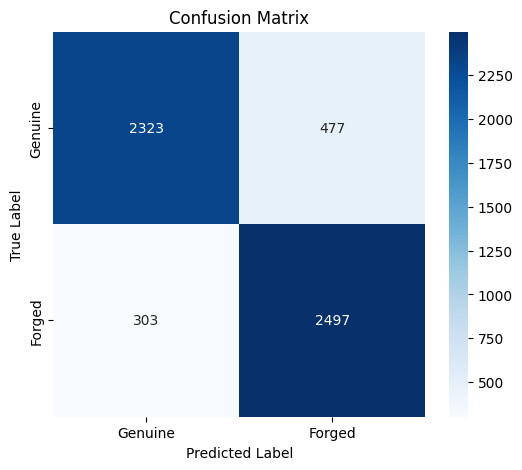

In [30]:
# Confusion Metrix
plot_confusion_matrix(conf_matrix)

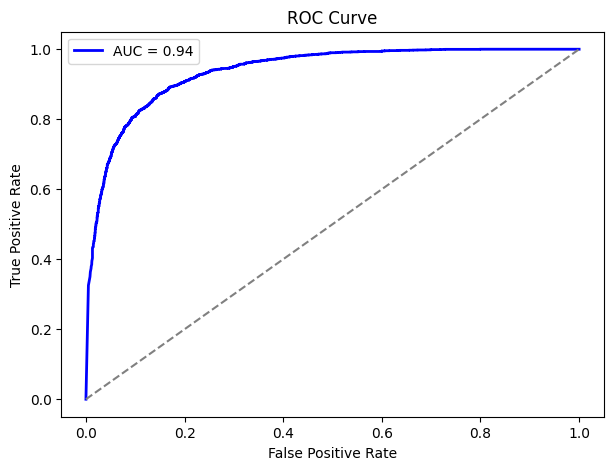

In [31]:
# AUC/ROC Curve
plot_roc_curve(y_test, y_pred_probs)

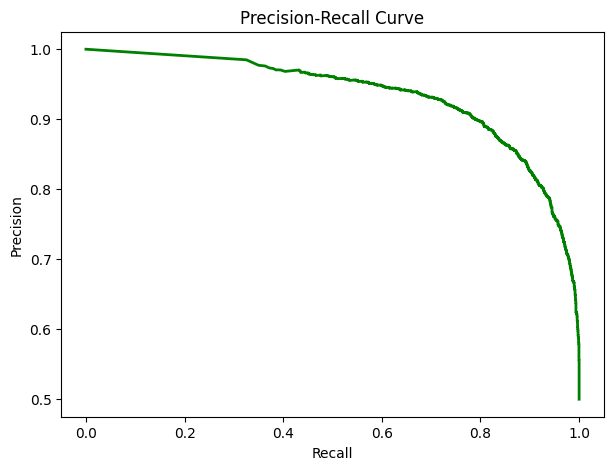

In [32]:
# Precision-Recall Curve
plot_precision_recall_curve(y_test, y_pred_probs)